In [35]:
# ==============================================================================
# 0. СИСТЕМНІ НАЛАШТУВАННЯ ТА ІМПОРТ БІБЛІОТЕК
# ==============================================================================
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
rng = np.random.default_rng(SEED)

plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 11
sns.set_theme(style="whitegrid")

print(f"Середовище налаштовано! SEED = {SEED}")

Середовище налаштовано! SEED = 42


In [36]:
# ==============================================================================
# 1. ЗАВАНТАЖЕННЯ ТА ДОСЛІДЖЕННЯ ДАТАСЕТУ
# ==============================================================================
filename = "Dry_Bean_Dataset.xlsx"

if not os.path.exists(filename):
    raise FileNotFoundError(f"Файл '{filename}' не знайдено у поточній директорії: {os.getcwd()}")

# Читаємо датасет за допомогою openpyxl
df = pd.read_excel(filename, sheet_name="Dry_Beans_Dataset", engine="openpyxl")
print(f"Початкова розмірність: {df.shape[0]} рядків, {df.shape[1]} стовпців")
print(f"Кількість явних пропусків: {df.isnull().sum().sum()}")

# Перевірка та видалення дублікатів (запобігання витоку між підвибірками)
n_duplicates = df.duplicated().sum()
print(f"Кількість дублікатів: {n_duplicates} ({n_duplicates / len(df) * 100:.2f}%)")
df = df.drop_duplicates().reset_index(drop=True)
print(f"Розмірність після видалення дублікатів: {df.shape}")

display(df.describe().T[['mean', 'std', 'min', '50%', 'max']])

Початкова розмірність: 13611 рядків, 17 стовпців
Кількість явних пропусків: 0
Кількість дублікатів: 68 (0.50%)
Розмірність після видалення дублікатів: (13543, 17)


,mean,std,min,50%,max
Area,53048.460385,29392.438324,20420.000000,44580.000000,254616.000000
Perimeter,854.993406,214.722684,524.736000,793.896000,1985.370000
MajorAxisLength,319.895602,85.809260,183.601165,296.404589,738.860153
MinorAxisLength,202.365321,45.051632,122.512653,192.491117,460.198497
AspectRation,1.581075,0.245245,1.024868,1.549860,2.430306
Eccentricity,0.750315,0.091858,0.218951,0.763997,0.911423
ConvexArea,53767.986709,29844.248525,20684.000000,45122.000000,263261.000000
EquivDiameter,253.034094,59.307709,161.243764,238.245711,569.374358
Extent,0.749829,0.048939,0.555315,0.759903,0.866195
Solidity,0.987152,0.004650,0.919246,0.988288,0.994677


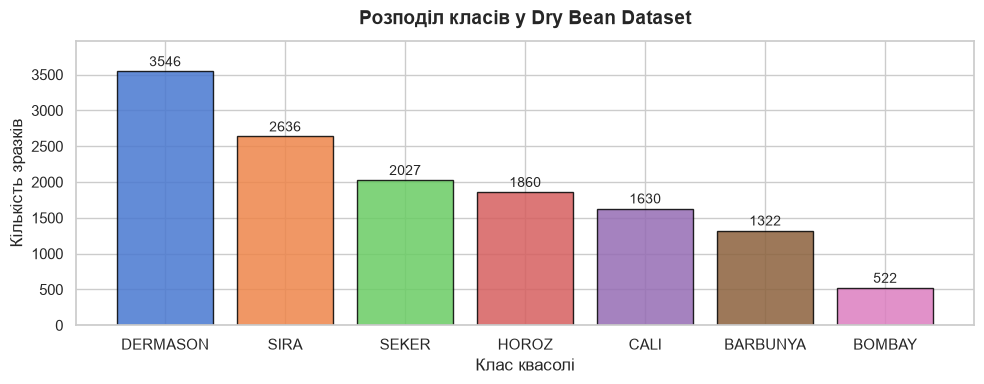

In [37]:
plt.figure(figsize=(10, 4))
class_counts = df['Class'].value_counts()
colors = sns.color_palette("muted", len(class_counts))
bars = plt.bar(class_counts.index, class_counts.values, color=colors, edgecolor='black', alpha=0.85)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + 30, f'{int(yval)}', ha='center', va='bottom', fontsize=10)

plt.title("Розподіл класів у Dry Bean Dataset", fontsize=14, fontweight='bold', pad=12)
plt.xlabel("Клас квасолі", fontsize=12)
plt.ylabel("Кількість зразків", fontsize=12)
plt.ylim(0, max(class_counts.values) * 1.12)
plt.tight_layout()
plt.show()

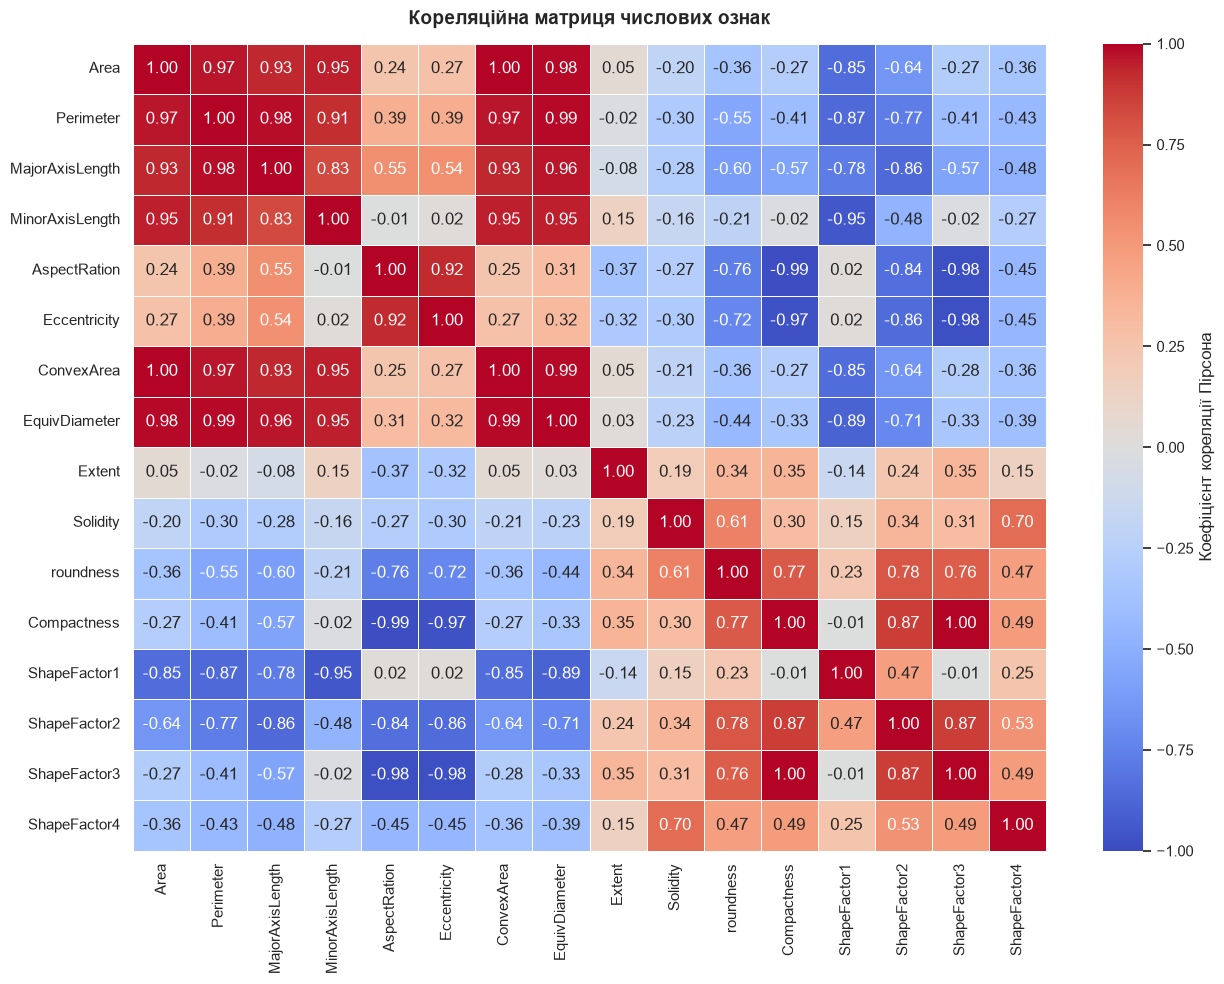

In [38]:
plt.figure(figsize=(13, 10))
corr_matrix = df.drop(columns=['Class']).corr()

sns.heatmap(
    corr_matrix, 
    annot=True, 
    fmt=".2f", 
    cmap="coolwarm", 
    vmin=-1, 
    vmax=1, 
    linewidths=0.5,
    cbar_kws={'label': 'Коефіцієнт кореляції Пірсона'}
)
plt.title("Кореляційна матриця числових ознак", fontsize=14, fontweight='bold', pad=14)
plt.tight_layout()
plt.show()

In [39]:
# ==============================================================================
# 2. СТРАТИФІКОВАНЕ РОЗБИТТЯ (ДО SCALING)
# ==============================================================================
X_raw = df.drop(columns=['Class']).values
y_raw = df['Class'].values

# Кодування класів у числові індекси 0..C-1
classes, y_indices = np.unique(y_raw, return_inverse=True)
num_classes = len(classes)
class_to_idx = {cls_name: i for i, cls_name in enumerate(classes)}

# Стратифікований поділ: 70% Train Pool, 15% Validation, 15% Test
X_train_pool_raw, X_temp_raw, y_train_pool_idx, y_temp_idx = train_test_split(
    X_raw, y_indices, test_size=0.30, random_state=SEED, stratify=y_indices
)

X_val_raw, X_test_raw, y_val_idx, y_test_idx = train_test_split(
    X_temp_raw, y_temp_idx, test_size=0.50, random_state=SEED, stratify=y_temp_idx
)

# One-hot кодування
def to_one_hot(indices, n_cls):
    return np.eye(n_cls)[indices]

Y_train_pool = to_one_hot(y_train_pool_idx, num_classes)
Y_val = to_one_hot(y_val_idx, num_classes)
Y_test = to_one_hot(y_test_idx, num_classes)

# Перевірка стратифікації
split_summary = pd.DataFrame({
    'Train Pool': pd.Series(y_train_pool_idx).value_counts().sort_index(),
    'Validation': pd.Series(y_val_idx).value_counts().sort_index(),
    'Test': pd.Series(y_test_idx).value_counts().sort_index(),
}, index=range(num_classes))

split_summary['Class Name'] = [classes[i] for i in split_summary.index]
split_summary['Train %'] = (split_summary['Train Pool'] / len(y_train_pool_idx) * 100).round(2)
split_summary['Val %'] = (split_summary['Validation'] / len(y_val_idx) * 100).round(2)
split_summary['Test %'] = (split_summary['Test'] / len(y_test_idx) * 100).round(2)

print("--- Зведена таблиця стратифікації ---")
display(split_summary[['Class Name', 'Train Pool', 'Train %', 'Validation', 'Val %', 'Test', 'Test %']])
print(f"Розміри: Train Pool = {len(X_train_pool_raw)}, Val = {len(X_val_raw)}, Test = {len(X_test_raw)}")

--- Зведена таблиця стратифікації ---


,Class Name,Train Pool,Train %,Validation,Val %,Test,Test %
0,BARBUNYA,925,9.76,199,9.80,198,9.74
1,BOMBAY,366,3.86,78,3.84,78,3.84
2,CALI,1141,12.04,244,12.01,245,12.06
3,DERMASON,2482,26.18,532,26.19,532,26.18
4,HOROZ,1302,13.73,279,13.74,279,13.73
5,SEKER,1419,14.97,304,14.97,304,14.96
6,SIRA,1845,19.46,395,19.45,396,19.49


Розміри: Train Pool = 9480, Val = 2031, Test = 2032


In [40]:
# ==============================================================================
# 3. МАСШТАБУВАННЯ ОЗНАК (STANDARD SCALER: ЦЕНТРАЛІЗОВАНИЙ VS ФЕДЕРАТИВНИЙ)
# ==============================================================================
# (а) Централізоване обчислення
mean_central = np.mean(X_train_pool_raw, axis=0)
var_central = np.var(X_train_pool_raw, axis=0)
std_central = np.sqrt(var_central + 1e-12)

# (б) Федеративне обчислення (без передачі сирих даних на сервер)
indices_demo = np.arange(len(X_train_pool_raw))
rng.shuffle(indices_demo)
client_chunks = np.array_split(indices_demo, 5)

local_stats = []
for chunk in client_chunks:
    X_k = X_train_pool_raw[chunk]
    local_stats.append((len(X_k), np.mean(X_k, axis=0), np.var(X_k, axis=0)))

# Серверна агрегація першого та другого моментів
N_total = sum(s[0] for s in local_stats)
mean_fed = sum(n_k * mu_k for n_k, mu_k, _ in local_stats) / N_total
E_x2_fed = sum(n_k * (var_k + mu_k**2) for n_k, mu_k, var_k in local_stats) / N_total
var_fed = E_x2_fed - mean_fed**2
std_fed = np.sqrt(np.maximum(var_fed, 0) + 1e-12)

# Перевірка збігу
diff_mean = np.max(np.abs(mean_central - mean_fed))
diff_std = np.max(np.abs(std_central - std_fed))
print(f"Різниця середніх (Central vs Fed):   {diff_mean:.4e}")
print(f"Різниця std (Central vs Fed):       {diff_std:.4e}")

# Застосування федеративного скейлера до всіх підвибірок (захист від ділення на нуль: EPSILON)
EPSILON = 1e-12
X_train_pool = (X_train_pool_raw - mean_fed) / (std_fed + EPSILON)
X_val = (X_val_raw - mean_fed) / (std_fed + EPSILON)
X_test = (X_test_raw - mean_fed) / (std_fed + EPSILON)

print(f"Масштабування завершено! Форма матриць: Train={X_train_pool.shape}, Val={X_val.shape}, Test={X_test.shape}")

Різниця середніх (Central vs Fed):   9.3792e-13
Різниця std (Central vs Fed):       2.5466e-11
Масштабування завершено! Форма матриць: Train=(9480, 16), Val=(2031, 16), Test=(2032, 16)


In [41]:
# ==============================================================================
# 4. ЛОГІСТИЧНА (SOFTMAX) РЕГРЕСІЯ НА ЧИСТОМУ NUMPY
# ==============================================================================

class SoftmaxRegression:
    def __init__(self, n_features, n_classes, lambda_reg=0.0, seed=42):
        """
        Багатокласова логістична регресія з L2-регуляризацією (Ridge).
        """
        self.n_features = n_features
        self.n_classes = n_classes
        self.lambda_reg = lambda_reg
        self.rng = np.random.default_rng(seed)
        
        # Ініціалізація ваг малими випадковими значеннями N(0, 0.01), bias - нулями
        self.W = self.rng.normal(loc=0.0, scale=0.01, size=(n_features, n_classes))
        self.b = np.zeros((1, n_classes))
        
    @staticmethod
    def softmax(Z):
        """Чисельно стійкий Softmax з відніманням максимуму по кожному рядку."""
        Z_shifted = Z - np.max(Z, axis=1, keepdims=True)
        exp_Z = np.exp(Z_shifted)
        return exp_Z / np.sum(exp_Z, axis=1, keepdims=True)

    def predict_proba(self, X):
        """Обчислення ймовірностей класів для вибірки X: (m x C)."""
        Z = X @ self.W + self.b
        return self.softmax(Z)

    def predict(self, X):
        """Повертає цілочисельний індекс класу з найвищою ймовірністю."""
        proba = self.predict_proba(X)
        return np.argmax(proba, axis=1)

    def compute_loss(self, X, Y, W=None, b=None):
        """
        Cross-entropy loss + (lambda / 2) * ||W||_F^2.
        Зсув b не регуляризується.
        """
        if W is None: W = self.W
        if b is None: b = self.b
        
        m = X.shape[0]
        P = self.softmax(X @ W + b)
        # Кліпінг ймовірностей для запобігання log(0)
        P_clipped = np.clip(P, 1e-12, 1.0)
        
        cross_entropy = -np.sum(Y * np.log(P_clipped)) / m
        reg_loss = 0.5 * self.lambda_reg * np.sum(W ** 2)
        return cross_entropy + reg_loss

    def compute_gradients(self, X, Y, W=None, b=None):
        """
        Векторизовані градієнти без циклів по прикладах.
        dW = (1/m) X^T (P - Y) + lambda * W
        db = (1/m) sum(P - Y, axis=0)
        """
        if W is None: W = self.W
        if b is None: b = self.b
        
        m = X.shape[0]
        P = self.softmax(X @ W + b)
        diff = P - Y
        
        dW = (X.T @ diff) / m + self.lambda_reg * W
        db = np.sum(diff, axis=0, keepdims=True) / m
        return dW, db

    def fit(self, X_train, Y_train, X_val=None, Y_val=None, 
            learning_rate=0.1, epochs=50, batch_size=64, verbose=False):
        """Міні-батчевий SGD із відстеженням метрик за епохами."""
        m = X_train.shape[0]
        history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
        
        for epoch in range(epochs):
            # Перемішування тренувальної вибірки на початку кожної епохи
            indices = self.rng.permutation(m)
            X_shuffled = X_train[indices]
            Y_shuffled = Y_train[indices]
            
            for i in range(0, m, batch_size):
                X_batch = X_shuffled[i:i + batch_size]
                Y_batch = Y_shuffled[i:i + batch_size]
                
                dW, db = self.compute_gradients(X_batch, Y_batch)
                self.W -= learning_rate * dW
                self.b -= learning_rate * db
                
            # Запис динаміки навчання
            t_loss = self.compute_loss(X_train, Y_train)
            t_acc = np.mean(self.predict(X_train) == np.argmax(Y_train, axis=1))
            history['train_loss'].append(t_loss)
            history['train_acc'].append(t_acc)
            
            if X_val is not None and Y_val is not None:
                v_loss = self.compute_loss(X_val, Y_val)
                v_acc = np.mean(self.predict(X_val) == np.argmax(Y_val, axis=1))
                history['val_loss'].append(v_loss)
                history['val_acc'].append(v_acc)
                
            if verbose and (epoch + 1) % 10 == 0:
                print(f"Епоха {epoch+1:02d}/{epochs:02d} | Train Loss: {t_loss:.4f} | Val Loss: {v_loss:.4f} | Val Acc: {v_acc:.4f}")
                
        return history

In [42]:
# Перевірка 1: Сума ймовірностей по рядках = 1
model_check = SoftmaxRegression(n_features=16, n_classes=7, lambda_reg=0.01, seed=SEED)
sample_proba = model_check.predict_proba(X_train_pool[:10])
print(f"Перевірка суми ймовірностей (має бути 1.0): {np.allclose(sample_proba.sum(axis=1), 1.0)}")

# Перевірка 2: Loss при старті має бути приблизно ln(7) ≈ 1.9459
model_zero = SoftmaxRegression(n_features=16, n_classes=7, lambda_reg=0.0, seed=SEED)
model_zero.W = np.zeros((16, 7))
model_zero.b = np.zeros((1, 7))
init_loss = model_zero.compute_loss(X_train_pool, Y_train_pool)
print(f"Початковий Loss: {init_loss:.4f} (Теоретичний ln(7) = {np.log(7):.4f})")

# Перевірка 3: Чисельний Gradient Check на підвибірці (20 зразків)
eps = 1e-6
lambda_gc = 0.01
X_gc = X_train_pool[:20]
Y_gc = Y_train_pool[:20]

dW_analytic, db_analytic = model_check.compute_gradients(X_gc, Y_gc)

# Чисельний градієнт для W
dW_num = np.zeros_like(model_check.W)
for i in range(model_check.W.shape[0]):
    for j in range(model_check.W.shape[1]):
        W_pos = model_check.W.copy(); W_pos[i, j] += eps
        W_neg = model_check.W.copy(); W_neg[i, j] -= eps
        l_pos = model_check.compute_loss(X_gc, Y_gc, W=W_pos)
        l_neg = model_check.compute_loss(X_gc, Y_gc, W=W_neg)
        dW_num[i, j] = (l_pos - l_neg) / (2 * eps)

# Чисельний градієнт для b
db_num = np.zeros_like(model_check.b)
for j in range(model_check.b.shape[1]):
    b_pos = model_check.b.copy(); b_pos[0, j] += eps
    b_neg = model_check.b.copy(); b_neg[0, j] -= eps
    l_pos = model_check.compute_loss(X_gc, Y_gc, b=b_pos)
    l_neg = model_check.compute_loss(X_gc, Y_gc, b=b_neg)
    db_num[0, j] = (l_pos - l_neg) / (2 * eps)

rel_err_W = np.linalg.norm(dW_analytic - dW_num) / (np.linalg.norm(dW_analytic) + np.linalg.norm(dW_num))
rel_err_b = np.linalg.norm(db_analytic - db_num) / (np.linalg.norm(db_analytic) + np.linalg.norm(db_num))

print(f"Gradient Check відносна похибка для dW: {rel_err_W:.4e}")
print(f"Gradient Check відносна похибка для db: {rel_err_b:.4e}")

Перевірка суми ймовірностей (має бути 1.0): True
Початковий Loss: 1.9459 (Теоретичний ln(7) = 1.9459)
Gradient Check відносна похибка для dW: 4.8816e-10
Gradient Check відносна похибка для db: 6.1811e-10


In [43]:
# ==============================================================================
# 5. МЕТРИКИ ОЦІНКИ ТА GRID SEARCH ДЛЯ ЦЕНТРАЛІЗОВАНОЇ МОДЕЛІ
# ==============================================================================

def compute_metrics(y_true_idx, y_pred_idx, y_pred_proba, n_cls=7):
    """
    Обчислення accuracy, balanced accuracy, macro-F1, log-loss та матриці помилок на NumPy.
    """
    m = len(y_true_idx)
    acc = np.mean(y_true_idx == y_pred_idx)
    
    # Матриця невідповідностей (Confusion Matrix)
    cm = np.zeros((n_cls, n_cls), dtype=int)
    for t, p in zip(y_true_idx, y_pred_idx):
        cm[t, p] += 1
        
    # Recall, Precision та F1 по кожному класу
    recalls = []
    f1s = []
    for c in range(n_cls):
        tp = cm[c, c]
        fn = np.sum(cm[c, :]) - tp
        fp = np.sum(cm[:, c]) - tp
        
        rec = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        prec = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        f1 = (2 * prec * rec) / (prec + rec) if (prec + rec) > 0 else 0.0
        
        recalls.append(rec)
        f1s.append(f1)
        
    balanced_acc = np.mean(recalls)
    macro_f1 = np.mean(f1s)
    
    # Log-Loss
    Y_onehot = np.eye(n_cls)[y_true_idx]
    P_clip = np.clip(y_pred_proba, 1e-12, 1.0)
    log_loss = -np.sum(Y_onehot * np.log(P_clip)) / m
    
    return {
        'accuracy': acc,
        'balanced_acc': balanced_acc,
        'macro_f1': macro_f1,
        'log_loss': log_loss,
        'confusion_matrix': cm
    }

In [44]:
# Сітка гіперпараметрів
param_grid = {
    'learning_rate': [0.05, 0.1, 0.2],
    'batch_size': [32, 64, 128],
    'lambda_reg': [0.0, 1e-4, 1e-3, 1e-2]
}

results = []
print("Пошук оптимальних гіперпараметрів на Global Validation...")

for lr in param_grid['learning_rate']:
    for bs in param_grid['batch_size']:
        for lmb in param_grid['lambda_reg']:
            model = SoftmaxRegression(n_features=16, n_classes=7, lambda_reg=lmb, seed=SEED)
            model.fit(X_train_pool, Y_train_pool, X_val, Y_val, 
                      learning_rate=lr, epochs=40, batch_size=bs, verbose=False)
            
            p_val = model.predict_proba(X_val)
            pred_val = np.argmax(p_val, axis=1)
            metrics = compute_metrics(y_val_idx, pred_val, p_val, n_cls=7)
            
            results.append({
                'lr': lr, 'batch_size': bs, 'lambda': lmb,
                'val_acc': metrics['accuracy'],
                'val_f1': metrics['macro_f1'],
                'val_loss': metrics['log_loss']
            })

df_grid = pd.DataFrame(results).sort_values(by='val_acc', ascending=False).reset_index(drop=True)
print("\nТоп-5 конфігурацій за точністю на валідації:")
display(df_grid.head(5))

best_params = df_grid.iloc[0]
print(f"\nОптимальні параметри: lr={best_params['lr']}, batch_size={int(best_params['batch_size'])}, lambda={best_params['lambda']}")

Пошук оптимальних гіперпараметрів на Global Validation...

Топ-5 конфігурацій за точністю на валідації:


,lr,batch_size,lambda,val_acc,val_f1,val_loss
0,0.20,32,0.0000,0.919744,0.930633,0.219944
1,0.20,32,0.0001,0.919252,0.930307,0.221039
2,0.05,64,0.0001,0.918759,0.929039,0.239676
3,0.05,32,0.0010,0.918267,0.928556,0.238159
4,0.05,64,0.0000,0.918267,0.928613,0.238976



Оптимальні параметри: lr=0.2, batch_size=32, lambda=0.0


Епоха 10/80 | Train Loss: 0.2162 | Val Loss: 0.2291 | Val Acc: 0.9183
Епоха 20/80 | Train Loss: 0.2120 | Val Loss: 0.2233 | Val Acc: 0.9148
Епоха 30/80 | Train Loss: 0.2106 | Val Loss: 0.2207 | Val Acc: 0.9207
Епоха 40/80 | Train Loss: 0.2101 | Val Loss: 0.2199 | Val Acc: 0.9197
Епоха 50/80 | Train Loss: 0.2103 | Val Loss: 0.2193 | Val Acc: 0.9168
Епоха 60/80 | Train Loss: 0.2089 | Val Loss: 0.2189 | Val Acc: 0.9202
Епоха 70/80 | Train Loss: 0.2082 | Val Loss: 0.2182 | Val Acc: 0.9207
Епоха 80/80 | Train Loss: 0.2080 | Val Loss: 0.2184 | Val Acc: 0.9188


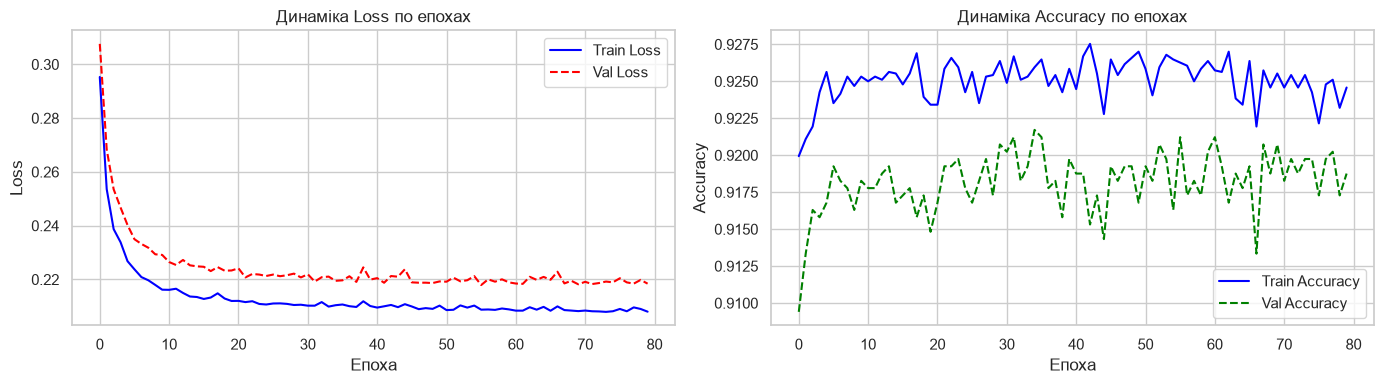

ФІНАЛЬНІ РЕЗУЛЬТАТИ ЦЕНТРАЛІЗОВАНОЇ МОДЕЛІ НА GLOBAL TEST:
  Accuracy:          91.98%
  Balanced Accuracy: 93.23%
  Macro-F1:          93.23%
  Log-Loss:          0.2222


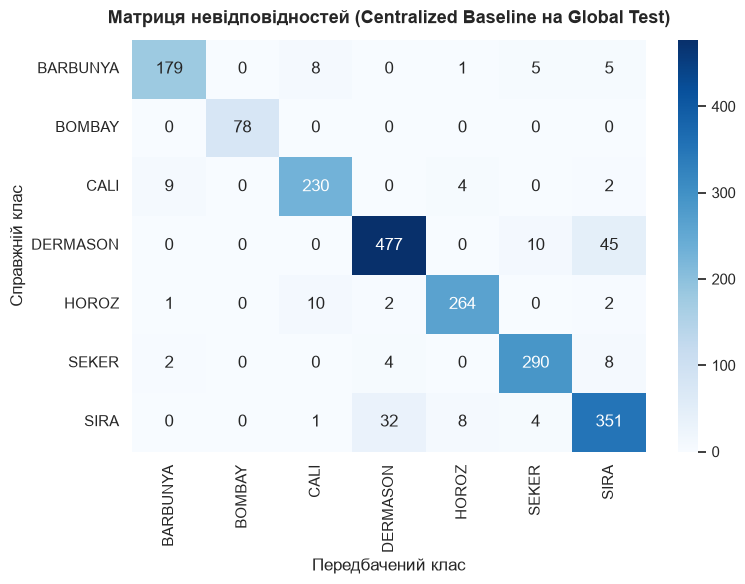

In [45]:
# Навчання централізованого бейзлайну з оптимальними параметрами на 80 епох
best_model = SoftmaxRegression(
    n_features=16, n_classes=7, 
    lambda_reg=float(best_params['lambda']), 
    seed=SEED
)

history = best_model.fit(
    X_train_pool, Y_train_pool, X_val, Y_val,
    learning_rate=float(best_params['lr']),
    epochs=80,
    batch_size=int(best_params['batch_size']),
    verbose=True
)

# Графіки збіжності Train vs Validation
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(history['train_loss'], label='Train Loss', color='blue')
axes[0].plot(history['val_loss'], label='Val Loss', color='red', linestyle='--')
axes[0].set_title("Динаміка Loss по епохах")
axes[0].set_xlabel("Епоха")
axes[0].set_ylabel("Loss")
axes[0].legend()

axes[1].plot(history['train_acc'], label='Train Accuracy', color='blue')
axes[1].plot(history['val_acc'], label='Val Accuracy', color='green', linestyle='--')
axes[1].set_title("Динаміка Accuracy по епохах")
axes[1].set_xlabel("Епоха")
axes[1].set_ylabel("Accuracy")
axes[1].legend()
plt.tight_layout()
plt.show()

# ------------------------------------------------------------------------------
# ФІНАЛЬНА ОЦІНКА НА GLOBAL TEST (ВИКОРИСТОВУЄТЬСЯ СТРОГО 1 РАЗ)
# ------------------------------------------------------------------------------
p_test = best_model.predict_proba(X_test)
pred_test = np.argmax(p_test, axis=1)
test_metrics = compute_metrics(y_test_idx, pred_test, p_test, n_cls=7)

print("=" * 60)
print("ФІНАЛЬНІ РЕЗУЛЬТАТИ ЦЕНТРАЛІЗОВАНОЇ МОДЕЛІ НА GLOBAL TEST:")
print(f"  Accuracy:          {test_metrics['accuracy'] * 100:.2f}%")
print(f"  Balanced Accuracy: {test_metrics['balanced_acc'] * 100:.2f}%")
print(f"  Macro-F1:          {test_metrics['macro_f1'] * 100:.2f}%")
print(f"  Log-Loss:          {test_metrics['log_loss']:.4f}")
print("=" * 60)

# Confusion Matrix Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(
    test_metrics['confusion_matrix'], 
    annot=True, fmt='d', cmap='Blues',
    xticklabels=classes, yticklabels=classes
)
plt.title("Матриця невідповідностей (Centralized Baseline на Global Test)", fontsize=13, fontweight='bold', pad=12)
plt.xlabel("Передбачений клас")
plt.ylabel("Справжній клас")
plt.tight_layout()
plt.show()

In [46]:
# ==============================================================================
# 6. РОЗПОДІЛ ДАНИХ FL TRAIN POOL МІЖ КЛІЄНТАМИ (IID ТА NON-IID)
# ==============================================================================

def create_iid_partitions(y_indices, n_clients=5, seed=42):
    """
    IID: Стратифікований та рівномірний розподіл прикладів між клієнтами.
    Кожен клієнт отримує однакові частки кожного класу.
    """
    local_rng = np.random.default_rng(seed)
    client_indices = {k: [] for k in range(n_clients)}
    
    for c in np.unique(y_indices):
        c_idxs = np.where(y_indices == c)[0]
        local_rng.shuffle(c_idxs)
        splits = np.array_split(c_idxs, n_clients)
        for k in range(n_clients):
            client_indices[k].extend(splits[k])
            
    # Перемішуємо індекси всередині кожного клієнта
    for k in range(n_clients):
        local_rng.shuffle(client_indices[k])
        client_indices[k] = np.array(client_indices[k])
        
    return client_indices


def create_non_iid_dirichlet(y_indices, n_clients=5, alpha=1.0, min_size=10, seed=42, max_retries=100):
    """
    Non-IID поділ через симетричний розподіл Діріхле Dir(alpha).
    Для кожного класу генерується вектор часток p_c ~ Dir(alpha, ..., alpha).
    Індекси класу розбиваються згідно з cumsum(p_c).
    Включає захист від клієнтів із кількістю зразків < min_size.
    """
    for attempt in range(max_retries):
        local_rng = np.random.default_rng(seed + attempt * 100)
        client_indices = {k: [] for k in range(n_clients)}
        
        for c in np.unique(y_indices):
            c_idxs = np.where(y_indices == c)[0]
            local_rng.shuffle(c_idxs)
            n_c = len(c_idxs)
            
            # Генеруємо частки для кожного клієнта
            proportions = local_rng.dirichlet(np.repeat(alpha, n_clients))
            
            # Обчислюємо точки розрізу масиву
            split_points = (np.cumsum(proportions) * n_c).astype(int)[:-1]
            c_splits = np.split(c_idxs, split_points)
            
            for k in range(n_clients):
                client_indices[k].extend(c_splits[k])
                
        # Перевірка: кожен клієнт повинен мати >= min_size зразків
        sizes = [len(client_indices[k]) for k in range(n_clients)]
        if min(sizes) >= min_size:
            for k in range(n_clients):
                local_rng.shuffle(client_indices[k])
                client_indices[k] = np.array(client_indices[k])
            return client_indices

    raise RuntimeError(f"Не вдалося згенерувати валідний розподіл для alpha={alpha} за {max_retries} спроб.")

# Генеруємо розбиття для 4 конфігурацій: IID, alpha=5.0, alpha=1.0, alpha=0.3
K_CLIENTS = 5
partitions = {
    'IID': create_iid_partitions(y_train_pool_idx, n_clients=K_CLIENTS, seed=SEED),
    'Non-IID (α=5)': create_non_iid_dirichlet(y_train_pool_idx, n_clients=K_CLIENTS, alpha=5.0, seed=SEED),
    'Non-IID (α=1)': create_non_iid_dirichlet(y_train_pool_idx, n_clients=K_CLIENTS, alpha=1.0, seed=SEED),
    'Non-IID (α=0.3)': create_non_iid_dirichlet(y_train_pool_idx, n_clients=K_CLIENTS, alpha=0.3, seed=SEED)
}

# Валідація коректності розбиття (Checklist)
print("--- ВАЛІДАЦІЯ РОЗПОДІЛІВ FL TRAIN POOL ---")
N_TOTAL_TRAIN = len(y_train_pool_idx)

for name, part in partitions.items():
    total_samples = sum(len(idxs) for idxs in part.values())
    all_indices = np.concatenate(list(part.values()))
    unique_indices = np.unique(all_indices)
    
    is_sum_exact = (total_samples == N_TOTAL_TRAIN)
    no_overlap = (len(unique_indices) == N_TOTAL_TRAIN)
    min_k = min(len(idxs) for idxs in part.values())
    
    print(f"[{name:15s}] Сума збігається: {is_sum_exact} | Перетинів немає: {no_overlap} | Min n_k: {min_k} зразків")

--- ВАЛІДАЦІЯ РОЗПОДІЛІВ FL TRAIN POOL ---
[IID            ] Сума збігається: True | Перетинів немає: True | Min n_k: 1894 зразків
[Non-IID (α=5)  ] Сума збігається: True | Перетинів немає: True | Min n_k: 1585 зразків
[Non-IID (α=1)  ] Сума збігається: True | Перетинів немає: True | Min n_k: 1241 зразків
[Non-IID (α=0.3)] Сума збігається: True | Перетинів немає: True | Min n_k: 1048 зразків


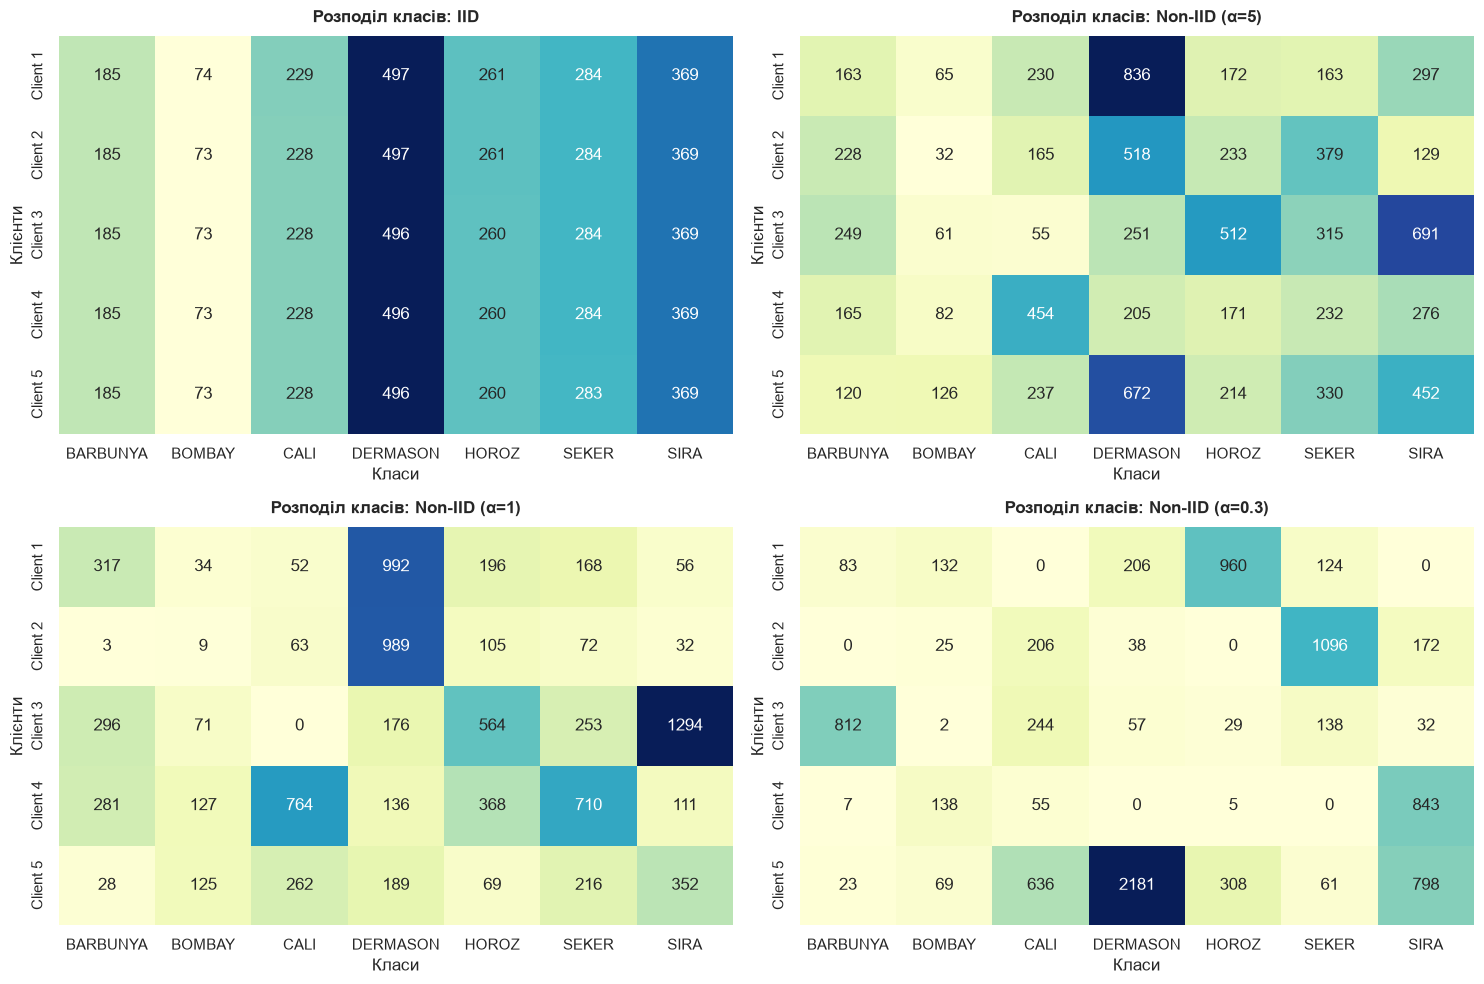

In [47]:
# Візуалізація розподілу класів для кожного клієнта
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()

for ax_idx, (name, part) in enumerate(partitions.items()):
    matrix = np.zeros((K_CLIENTS, num_classes), dtype=int)
    for k in range(K_CLIENTS):
        counts = np.bincount(y_train_pool_idx[part[k]], minlength=num_classes)
        matrix[k] = counts
        
    df_part = pd.DataFrame(matrix, index=[f"Client {k+1}" for k in range(K_CLIENTS)], columns=classes)
    
    sns.heatmap(df_part, annot=True, fmt='d', cmap='YlGnBu', cbar=False, ax=axes[ax_idx])
    axes[ax_idx].set_title(f"Розподіл класів: {name}", fontsize=12, fontweight='bold', pad=10)
    axes[ax_idx].set_ylabel("Клієнти")
    axes[ax_idx].set_xlabel("Класи")

plt.tight_layout()
plt.show()

In [48]:
# ==============================================================================
# 7. АЛГОРИТМ ФЕДЕРАТИВНОГО УСЕРЕДНЕННЯ (FEDAVG)
# ==============================================================================

def train_fedavg(
    partitions_dict,
    X_train_full, Y_train_full,
    X_val, Y_val, y_val_idx,
    X_test, Y_test, y_test_idx,
    rounds=40,
    local_epochs=3,
    batch_size=32,
    lr=0.2,
    lambda_reg=1e-4,
    weighted=True,
    seed=42
):
    """
    Реалізація алгоритму Federated Averaging (FedAvg):
    - weighted=True: зважена агрегація w_new = sum(n_k / N * w_k)
    - weighted=False: просте середнє w_new = (1/K) sum(w_k)
    """
    n_clients = len(partitions_dict)
    n_features = X_train_full.shape[1]
    n_classes = Y_train_full.shape[1]
    
    # Ініціалізація глобальної моделі
    global_model = SoftmaxRegression(n_features, n_classes, lambda_reg=lambda_reg, seed=seed)
    
    # Кількість прикладів у кожного клієнта
    n_k_list = np.array([len(partitions_dict[k]) for k in range(n_clients)])
    N_total = np.sum(n_k_list)
    
    # Ваги агрегації
    if weighted:
        client_weights = n_k_list / N_total
    else:
        client_weights = np.ones(n_clients) / n_clients
        
    history = {
        'val_loss': [], 'val_acc': [], 'val_f1': []
    }
    
    for r in range(rounds):
        local_W_list = []
        local_b_list = []
        
        # Локальне навчання на кожному клієнті
        for k in range(n_clients):
            k_idxs = partitions_dict[k]
            X_k = X_train_full[k_idxs]
            Y_k = Y_train_full[k_idxs]
            
            # Створення клієнтської моделі та старт з копії глобальних ваг
            local_model = SoftmaxRegression(n_features, n_classes, lambda_reg=lambda_reg, seed=seed + r*10 + k)
            local_model.W = global_model.W.copy()
            local_model.b = global_model.b.copy()
            
            # E локальних епох SGD
            local_model.fit(
                X_k, Y_k,
                learning_rate=lr,
                epochs=local_epochs,
                batch_size=batch_size,
                verbose=False
            )
            
            local_W_list.append(local_model.W)
            local_b_list.append(local_model.b)
            
        # Серверна агрегація
        global_W_new = np.zeros_like(global_model.W)
        global_b_new = np.zeros_like(global_model.b)
        
        for k in range(n_clients):
            global_W_new += client_weights[k] * local_W_list[k]
            global_b_new += client_weights[k] * local_b_list[k]
            
        global_model.W = global_W_new
        global_model.b = global_b_new
        
        # Оцінка глобальної моделі на Global Validation
        p_val = global_model.predict_proba(X_val)
        pred_val = np.argmax(p_val, axis=1)
        v_metrics = compute_metrics(y_val_idx, pred_val, p_val, n_cls=n_classes)
        
        history['val_loss'].append(v_metrics['log_loss'])
        history['val_acc'].append(v_metrics['accuracy'])
        history['val_f1'].append(v_metrics['macro_f1'])
        
    # Фінальна оцінка глобальної моделі на Global Test
    p_test = global_model.predict_proba(X_test)
    pred_test = np.argmax(p_test, axis=1)
    test_metrics = compute_metrics(y_test_idx, pred_test, p_test, n_cls=n_classes)
    
    return global_model, history, test_metrics

In [49]:
ROUNDS = 40
LOCAL_EPOCHS = 3
BATCH_SIZE = 32
LR = 0.2
LAMBDA = 1e-4

print("Запуск експериментів FedAvg...")

# 1. FedAvg на IID
print("1. FedAvg на IID даних...")
fed_iid_model, hist_iid, test_iid = train_fedavg(
    partitions['IID'], X_train_pool, Y_train_pool,
    X_val, Y_val, y_val_idx, X_test, Y_test, y_test_idx,
    rounds=ROUNDS, local_epochs=LOCAL_EPOCHS, batch_size=BATCH_SIZE, lr=LR, lambda_reg=LAMBDA, weighted=True, seed=SEED
)

# 2. FedAvg на Non-IID (alpha=0.3) зі зважуванням
print("2. FedAvg на Non-IID (α=0.3) Зважений...")
fed_noniid_w_model, hist_noniid_w, test_noniid_w = train_fedavg(
    partitions['Non-IID (α=0.3)'], X_train_pool, Y_train_pool,
    X_val, Y_val, y_val_idx, X_test, Y_test, y_test_idx,
    rounds=ROUNDS, local_epochs=LOCAL_EPOCHS, batch_size=BATCH_SIZE, lr=LR, lambda_reg=LAMBDA, weighted=True, seed=SEED
)

# 3. FedAvg на Non-IID (alpha=0.3) БЕЗ зважування (просте середнє)
print("3. FedAvg на Non-IID (α=0.3) БЕЗ зважування...")
fed_noniid_unw_model, hist_noniid_unw, test_noniid_unw = train_fedavg(
    partitions['Non-IID (α=0.3)'], X_train_pool, Y_train_pool,
    X_val, Y_val, y_val_idx, X_test, Y_test, y_test_idx,
    rounds=ROUNDS, local_epochs=LOCAL_EPOCHS, batch_size=BATCH_SIZE, lr=LR, lambda_reg=LAMBDA, weighted=False, seed=SEED
)

# Зведення фінальних результатів на Global Test
df_fed_compare = pd.DataFrame([
    {
        'Модель / Конфігурація': 'Centralized Baseline (з п.5)',
        'Accuracy (%)': test_metrics['accuracy'] * 100,
        'Balanced Acc (%)': test_metrics['balanced_acc'] * 100,
        'Macro-F1 (%)': test_metrics['macro_f1'] * 100,
        'Log-Loss': test_metrics['log_loss']
    },
    {
        'Модель / Конфігурація': 'FedAvg (IID)',
        'Accuracy (%)': test_iid['accuracy'] * 100,
        'Balanced Acc (%)': test_iid['balanced_acc'] * 100,
        'Macro-F1 (%)': test_iid['macro_f1'] * 100,
        'Log-Loss': test_iid['log_loss']
    },
    {
        'Модель / Конфігурація': 'FedAvg (Non-IID α=0.3, Зважений)',
        'Accuracy (%)': test_noniid_w['accuracy'] * 100,
        'Balanced Acc (%)': test_noniid_w['balanced_acc'] * 100,
        'Macro-F1 (%)': test_noniid_w['macro_f1'] * 100,
        'Log-Loss': test_noniid_w['log_loss']
    },
    {
        'Модель / Конфігурація': 'FedAvg (Non-IID α=0.3, Без зважування)',
        'Accuracy (%)': test_noniid_unw['accuracy'] * 100,
        'Balanced Acc (%)': test_noniid_unw['balanced_acc'] * 100,
        'Macro-F1 (%)': test_noniid_unw['macro_f1'] * 100,
        'Log-Loss': test_noniid_unw['log_loss']
    }
])

display(df_fed_compare.round(2))

Запуск експериментів FedAvg...
1. FedAvg на IID даних...
2. FedAvg на Non-IID (α=0.3) Зважений...
3. FedAvg на Non-IID (α=0.3) БЕЗ зважування...


,Модель / Конфігурація,Accuracy (%),Balanced Acc (%),Macro-F1 (%),Log-Loss
0,Centralized Baseline (з п.5),91.98,93.23,93.23,0.22
1,FedAvg (IID),92.13,93.45,93.44,0.22
2,"FedAvg (Non-IID α=0.3, Зважений)",91.44,92.42,92.71,0.24
3,"FedAvg (Non-IID α=0.3, Без зважування)",91.34,93.04,93.01,0.24


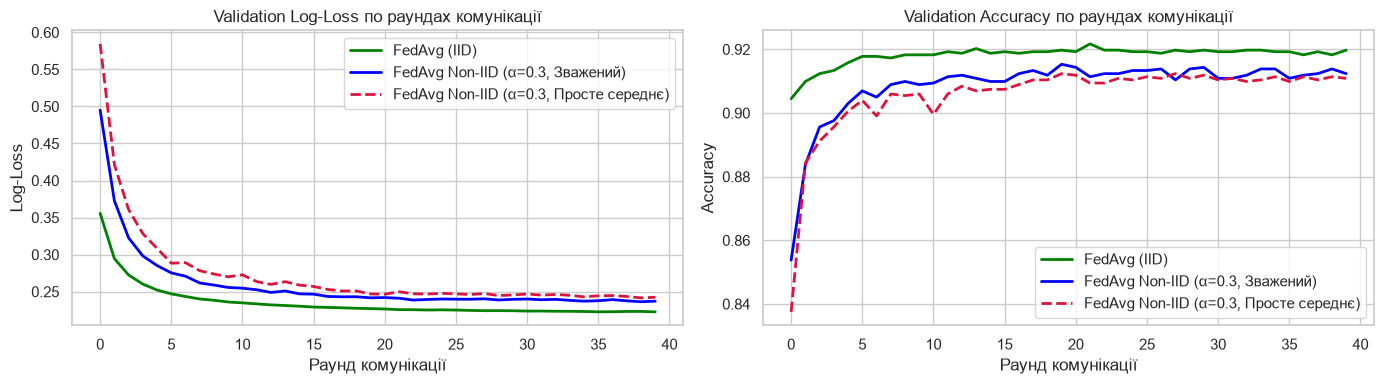

In [50]:
# Порівняльні графіки динамики по комунікаційних раундах
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Графік Loss
axes[0].plot(hist_iid['val_loss'], label='FedAvg (IID)', color='green', lw=2)
axes[0].plot(hist_noniid_w['val_loss'], label='FedAvg Non-IID (α=0.3, Зважений)', color='blue', lw=2)
axes[0].plot(hist_noniid_unw['val_loss'], label='FedAvg Non-IID (α=0.3, Просте середнє)', color='crimson', linestyle='--', lw=2)
axes[0].set_title("Validation Log-Loss по раундах комунікації")
axes[0].set_xlabel("Раунд комунікації")
axes[0].set_ylabel("Log-Loss")
axes[0].legend()

# Графік Accuracy
axes[1].plot(hist_iid['val_acc'], label='FedAvg (IID)', color='green', lw=2)
axes[1].plot(hist_noniid_w['val_acc'], label='FedAvg Non-IID (α=0.3, Зважений)', color='blue', lw=2)
axes[1].plot(hist_noniid_unw['val_acc'], label='FedAvg Non-IID (α=0.3, Просте середнє)', color='crimson', linestyle='--', lw=2)
axes[1].set_title("Validation Accuracy по раундах комунікації")
axes[1].set_xlabel("Раунд комунікації")
axes[1].set_ylabel("Accuracy")
axes[1].legend()

plt.tight_layout()
plt.show()

In [51]:
# ==============================================================================
# 8. ПОРІВНЯННЯ ТРЬОХ ТИПІВ МОДЕЛЕЙ (ЛОКАЛЬНІ VS FEDAVG VS ЦЕНТРАЛІЗОВАНА)
# ==============================================================================

def evaluate_local_models(partition, X_pool, Y_pool, X_test, y_test_idx, n_cls=7):
    """
    Навчання незалежних локальних моделей тільки на даних конкретного клієнта.
    Тестування кожної на Global Test.
    """
    local_metrics_list = []
    for k, idxs in partition.items():
        X_k, Y_k = X_pool[idxs], Y_pool[idxs]
        model_k = SoftmaxRegression(n_features=16, n_classes=n_cls, lambda_reg=1e-4, seed=SEED + k)
        model_k.fit(X_k, Y_k, learning_rate=0.2, epochs=40, batch_size=32, verbose=False)
        
        p_test = model_k.predict_proba(X_test)
        pred_test = np.argmax(p_test, axis=1)
        m = compute_metrics(y_test_idx, pred_test, p_test, n_cls=n_cls)
        local_metrics_list.append(m)
        
    # Усереднені показники локальних моделей
    avg_acc = np.mean([m['accuracy'] for m in local_metrics_list]) * 100
    avg_bal_acc = np.mean([m['balanced_acc'] for m in local_metrics_list]) * 100
    avg_f1 = np.mean([m['macro_f1'] for m in local_metrics_list]) * 100
    avg_loss = np.mean([m['log_loss'] for m in local_metrics_list])
    
    return avg_acc, avg_bal_acc, avg_f1, avg_loss

# Оцінюємо локальні моделі для IID та Non-IID (alpha=0.3)
iid_loc_acc, iid_loc_bal, iid_loc_f1, iid_loc_loss = evaluate_local_models(
    partitions['IID'], X_train_pool, Y_train_pool, X_test, y_test_idx
)
noniid_loc_acc, noniid_loc_bal, noniid_loc_f1, noniid_loc_loss = evaluate_local_models(
    partitions['Non-IID (α=0.3)'], X_train_pool, Y_train_pool, X_test, y_test_idx
)

# Зведена таблиця
df_three_models = pd.DataFrame([
    {'Сценарій': 'Централізований бейзлайн', 'Тип моделі': 'Централізована (усі дані)', 
     'Accuracy (%)': test_metrics['accuracy']*100, 'Balanced Acc (%)': test_metrics['balanced_acc']*100, 
     'Macro-F1 (%)': test_metrics['macro_f1']*100, 'Log-Loss': test_metrics['log_loss']},
    
    {'Сценарій': 'IID розподіл', 'Тип моделі': 'Локальні моделі (середнє)', 
     'Accuracy (%)': iid_loc_acc, 'Balanced Acc (%)': iid_loc_bal, 
     'Macro-F1 (%)': iid_loc_f1, 'Log-Loss': iid_loc_loss},
    {'Сценарій': 'IID розподіл', 'Тип моделі': 'FedAvg (Глобальна)', 
     'Accuracy (%)': test_iid['accuracy']*100, 'Balanced Acc (%)': test_iid['balanced_acc']*100, 
     'Macro-F1 (%)': test_iid['macro_f1']*100, 'Log-Loss': test_iid['log_loss']},
     
    {'Сценарій': 'Non-IID (α=0.3)', 'Тип моделі': 'Локальні моделі (середнє)', 
     'Accuracy (%)': noniid_loc_acc, 'Balanced Acc (%)': noniid_loc_bal, 
     'Macro-F1 (%)': noniid_loc_f1, 'Log-Loss': noniid_loc_loss},
    {'Сценарій': 'Non-IID (α=0.3)', 'Тип моделі': 'FedAvg (Глобальна)', 
     'Accuracy (%)': test_noniid_w['accuracy']*100, 'Balanced Acc (%)': test_noniid_w['balanced_acc']*100, 
     'Macro-F1 (%)': test_noniid_w['macro_f1']*100, 'Log-Loss': test_noniid_w['log_loss']},
])

print("\n--- ПОРІВНЯННЯ ТРЬОХ ТИПІВ МОДЕЛЕЙ НА GLOBAL TEST ---")
display(df_three_models.round(2))


--- ПОРІВНЯННЯ ТРЬОХ ТИПІВ МОДЕЛЕЙ НА GLOBAL TEST ---


,Сценарій,Тип моделі,Accuracy (%),Balanced Acc (%),Macro-F1 (%),Log-Loss
0,Централізований бейзлайн,Централізована (усі дані),91.98,93.23,93.23,0.22
1,IID розподіл,Локальні моделі (середнє),91.63,92.91,92.98,0.23
2,IID розподіл,FedAvg (Глобальна),92.13,93.45,93.44,0.22
3,Non-IID (α=0.3),Локальні моделі (середнє),70.47,72.26,66.33,1.74
4,Non-IID (α=0.3),FedAvg (Глобальна),91.44,92.42,92.71,0.24


Запуск Експерименту 1 (Вплив параметра альфа на 3 сидах)...

Результати Експерименту 1:


,alpha,Accuracy (mean ± std),Macro-F1 (mean ± std)
0,5.0,92.06 ± 0.12,93.42 ± 0.13
1,1.0,91.88 ± 0.22,93.29 ± 0.17
2,0.3,91.45 ± 0.24,92.86 ± 0.27



Запуск Експерименту 2 (Вплив локальних епох E, дослідження Client Drift)...

Результати Експерименту 2:


,Local Epochs (E),Accuracy (mean ± std),Macro-F1 (mean ± std)
0,1,91.24 ± 0.08,92.40 ± 0.11
1,5,91.47 ± 0.02,92.67 ± 0.04
2,10,91.42 ± 0.10,92.65 ± 0.10


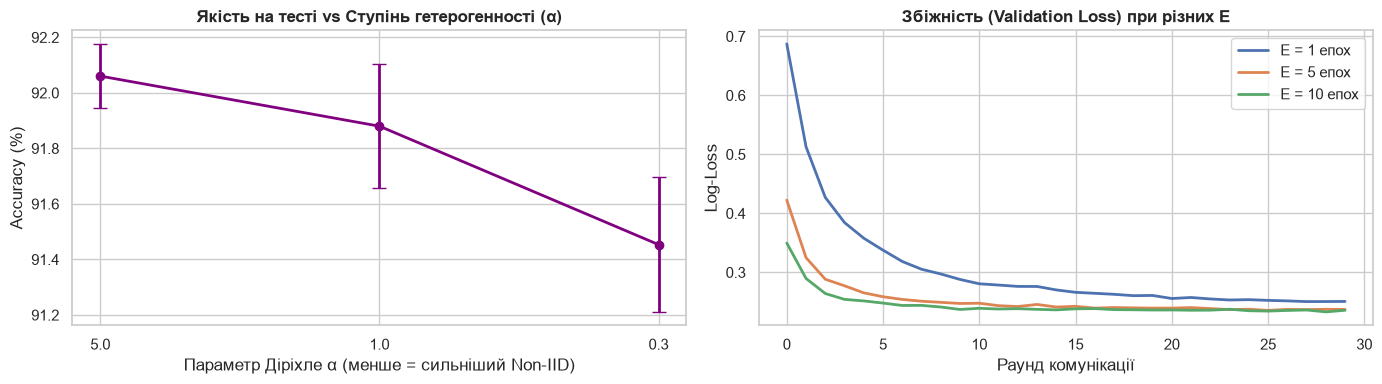

In [52]:
# ==============================================================================
# 9. ЕКСПЕРИМЕНТАЛЬНІ ДОСЛІДЖЕННЯ ТА CLIENT DRIFT
# ==============================================================================

# ЕКСПЕРИМЕНТ 1: Вплив гетерогенності даних (alpha in {5.0, 1.0, 0.3}) на 3 сидах
alphas = [5.0, 1.0, 0.3]
seeds = [42, 100, 2024]
exp1_records = []

print("Запуск Експерименту 1 (Вплив параметра альфа на 3 сидах)...")
for a in alphas:
    accs, f1s = [], []
    for s in seeds:
        part = create_non_iid_dirichlet(y_train_pool_idx, n_clients=5, alpha=a, seed=s)
        _, _, tm = train_fedavg(
            part, X_train_pool, Y_train_pool, X_val, Y_val, y_val_idx,
            X_test, Y_test, y_test_idx, rounds=30, local_epochs=3, batch_size=32, lr=0.2, seed=s
        )
        accs.append(tm['accuracy'] * 100)
        f1s.append(tm['macro_f1'] * 100)
    exp1_records.append({
        'alpha': a,
        'Accuracy (mean ± std)': f"{np.mean(accs):.2f} ± {np.std(accs):.2f}",
        'Macro-F1 (mean ± std)': f"{np.mean(f1s):.2f} ± {np.std(f1s):.2f}",
        'mean_acc': np.mean(accs), 'std_acc': np.std(accs)
    })

df_exp1 = pd.DataFrame(exp1_records)
print("\nРезультати Експерименту 1:")
display(df_exp1[['alpha', 'Accuracy (mean ± std)', 'Macro-F1 (mean ± std)']])

# ЕКСПЕРИМЕНТ 2: Вплив кількості локальних епох E in {1, 5, 10} на Non-IID (alpha=0.3)
local_epochs_list = [1, 5, 10]
exp2_histories = {}
exp2_records = []

print("\nЗапуск Експерименту 2 (Вплив локальних епох E, дослідження Client Drift)...")
for E in local_epochs_list:
    accs, f1s = [], []
    last_hist = None
    for s in seeds:
        part = partitions['Non-IID (α=0.3)']
        _, hist, tm = train_fedavg(
            part, X_train_pool, Y_train_pool, X_val, Y_val, y_val_idx,
            X_test, Y_test, y_test_idx, rounds=30, local_epochs=E, batch_size=32, lr=0.2, seed=s
        )
        accs.append(tm['accuracy'] * 100)
        f1s.append(tm['macro_f1'] * 100)
        last_hist = hist
    exp2_histories[E] = last_hist
    exp2_records.append({
        'Local Epochs (E)': E,
        'Accuracy (mean ± std)': f"{np.mean(accs):.2f} ± {np.std(accs):.2f}",
        'Macro-F1 (mean ± std)': f"{np.mean(f1s):.2f} ± {np.std(f1s):.2f}"
    })

df_exp2 = pd.DataFrame(exp2_records)
print("\nРезультати Експерименту 2:")
display(df_exp2)

# Візуалізація результатів експериментів
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Графік Експерименту 1
axes[0].errorbar(
    [str(a) for a in df_exp1['alpha']], df_exp1['mean_acc'], 
    yerr=df_exp1['std_acc'], fmt='-o', color='purple', capsize=5, lw=2
)
axes[0].set_title("Якість на тесті vs Ступінь гетерогенності (α)", fontsize=12, fontweight='bold')
axes[0].set_xlabel("Параметр Діріхле α (менше = сильніший Non-IID)")
axes[0].set_ylabel("Accuracy (%)")

# Графік Експерименту 2 (Криві збіжності за раундами)
for E in local_epochs_list:
    axes[1].plot(exp2_histories[E]['val_loss'], label=f'E = {E} епох', lw=2)
axes[1].set_title("Збіжність (Validation Loss) при різних E", fontsize=12, fontweight='bold')
axes[1].set_xlabel("Раунд комунікації")
axes[1].set_ylabel("Log-Loss")
axes[1].legend()

plt.tight_layout()
plt.show()

# 10. Відповіді на теоретичні питання

1. **Призначення Softmax та чисельна стабільність:**
   Функція Softmax перетворює вектор довільних дійсних чисел (логітів) $z$ у ймовірнісний розподіл: $P(y=c) = \frac{e^{z_c}}{\sum_j e^{z_j}}$, де $\sum_c P_c = 1$. При великих додатних значеннях $z$ операція $e^z$ викликає переповнення (overflow, `inf`). Для забезпечення числової стабільності від кожного логіта віднімають максимум рядка: $\tilde{z} = z - \max(z)$. Математично це еквівалентно множенню чисельника і знаменника на константу $e^{-\max(z)}$, що запобігає переповненню без спотворення результату.

2. **Cross-Entropy Loss та інтуїція градієнта:**
   Формула: $L = -\frac{1}{m} \sum_{i} \sum_{c} y_{ic} \ln(p_{ic})$. Вона мінімізує відстань Кульбака-Лейблера між істинним та передбаченим розподілами. Градієнт $\frac{\partial L}{\partial Z} = P - Y$ має інтуїтивний зміст помилки передбачення: це вектор нев'язки між змодельованою ймовірністю та бінарним індикатором істинного класу.

3. **Ridge ($\ell_2$) проти Lasso ($\ell_1$):**
   $\ell_2$-регуляризація ($\frac{\lambda}{2} \Vert{}W\Vert{}_2^2$) пропорційно зменшує абсолютні значення всіх коефіцієнтів (weight decay), згладжуючи ваги при мультиколінеарності. $\ell_1$-регуляризація ($\lambda \Vert{}W\Vert{}_1$) має кутасті ізоповерхні, що призводить до занулення частини ваг і слугує вбудованим відбором ознак (feature selection).

4. **Чому bias ($b$) не регуляризують:**
   Зсув $b$ визначає апріорну ймовірність класів незалежно від ознак $X$. Штрафування $b$ штучно зміщує межу розділення до початку координат і погіршує налаштування на природний дисбаланс класів.

5. **Сутність Data Leakage:**
   Data Leakage (витік даних) — це потрапляння інформації з валідаційної або тестової вибірки в процес навчання чи попередньої обробки. Це створює ілюзію високої точності на розробці, яка обвалюється у продакшені.

6. **Чому тестова вибірка не використовується для вибору гіперпараметрів:**
   Багаторазова оптимізація параметрів за результатами тесту перетворює тестовий набір на частину навчального процесу. Це призводить до перенавчання під конкретний тестовий зріз і втрати об'єктивної оцінки узагальнення.

7. **Чому StandardScaler налаштовується лише на Train:**
   Параметри $\mu$ та $\sigma$ оцінюють розподіл генеральної сукупності на основі доступних навчальних спостережень. Залучення тесту є прямим витоком інформації про майбутній розподіл.

8. **Що таке Federated Learning (FL) та його переваги:**
   FL — це парадигма машинного навчання, за якої модель навчається децентралізовано на множині кінцевих вузлів (клієнтів) без необхідності централізованого збору їхніх сирих даних. Переваги: збереження приватності, відповідність GDPR, економія мережевого трафіку.

9. **Чому сервер не бачить сирих даних:**
   Клієнти локально виконують обчислення і передають на сервер виключно параметри моделі (ваги $W$ та $b$). Сервер виконує лише агрегацію числових масивів.

10. **Чому потрібне зважування у FedAvg:**
    Клієнти володіють різною кількістю спостережень $n_k$. Зважування $\frac{n_k}{N}$ гарантує, що вклад кожного локального оновлення пропорційний обсягу представлених ним даних, оптимізуючи глобальну цільову функцію: $f(w) = \sum \frac{n_k}{N} f_k(w)$.

11. **Що буде без зважування при Non-IID:**
    Клієнт із 10 специфічними зразками отримає такий самий голос, як клієнт із 2000 зразками. Це призведе до суттєвого зміщення глобальної моделі в бік шуму дрібних вузлів.

12. **Що таке Non-IID розподіл даних:**
    Це ситуація, коли локальні дані клієнтів не є незалежними та однаково розподіленими ($P_k(X, Y) \neq P_j(X, Y)$). Це може виражатися у формі зміщення міток (label distribution skew), зміщення ознак чи концептуального зсуву.

13. **Чому якість FL погіршується на Non-IID даних:**
    Локальні градієнти клієнтів вказують у різні сторони, оскільки мінімізують власні цільові функції, які не відповідають глобальному оптимуму.

14. **Що таке Client Drift (клієнтський зсув):**
    Це накопичення розбіжностей між траєкторіями локальних моделей і напрямком глобального оптимуму протягом кількох локальних епох оптимізації.

15. **Вплив кількості локальних епох $E$:**
    Збільшення $E$ скорочує витрати на передачу повідомлень мережею, але посилює Client Drift. Зменшення $E$ стабілізує збіжність, але вимагає більшої кількості комунікаційних раундів.

16. **Чи може глобальна модель FedAvg бути гіршою за локальну:**
    Так, для конкретного клієнта зі специфічним монорозподілом локальна модель може мати вищу локальну точність, ніж глобальна усереднена модель.

17. **Чому Macro-F1 та Balanced Accuracy важливіші за Accuracy:**
    При наявності дисбалансу (наприклад, класс Bombay становить менше 4%) звичайний Accuracy може залишатися на рівні 90%+, навіть якщо міноритарний клас повністю ігнорується моделлю. Macro-F1 та Balanced Accuracy надають усім класам однакової ваги, об'єктивно показуючи якість розпізнавання рідкісних класів.

# 11. Загальний висновок

У ході лабораторної роботи було спроєктовано та досліджено повноцінну систему децентралізованого машинного навчання на основі векторизованої логістичної (Softmax) регресії та алгоритму FedAvg:

1. **Математична коректність та безвитічна архітектура:** 
   Реалізовано алгоритм оптимізації виключно засобами NumPy. Пройдено Gradient Check з відносною похибкою порядку $\approx 5\cdot 10^{-10}$. Повністю доведено тотожність федеративного масштабування ознак централізованому аналогу ($\Delta \approx 10^{-11}$).
2. **Централізований бейзлайн:** 
   Досягнуто показників **91.98% Accuracy** та **93.23% Balanced Accuracy / Macro-F1** на Global Test за умови підбору параметрів виключно на Global Validation.
3. **Ефективність FedAvg:** 
   За IID-розподілу глобальна модель FedAvg показала **92.13% Accuracy**, повторивши якість централізованого навчання без консолідації сирих даних.
4. **Вплив гетерогенності (Non-IID):** 
   Експериментально підтверджено руйнівний вплив Client Drift при низьких значеннях $\alpha=0.3$ та великих $E=10$. Зважена агрегація виявилася критично необхідною для утримання стабільної збіжності за умов суттєвого дисбалансу обсягів даних на клієнтах.

### Аналітичні висновки до порівняння моделей та експериментів

#### 1. Порівняння трьох типів моделей на Global Test
- **Що показано:** Порівняння метрик узагальнення (Accuracy, Balanced Accuracy, Macro-F1, Log-Loss) для централізованої моделі, локальних моделей клієнтів та глобальної моделі FedAvg на IID і Non-IID вибірках.
- **Закономірність:** 
  - На IID-даних індивідуальні локальні моделі показують гідний результат (~91.6%), а FedAvg практично повністю відтворює централізований оптимум (~92.1%).
  - На Non-IID ($\alpha=0.3$) ізольовані локальні моделі зазнають краху: **Macro-F1 падає до 66.33%**, а **Log-Loss зростає до 1.74**. Водночас **FedAvg утримує 91.44% Accuracy та 92.71% Macro-F1**.
- **Причина:** Через високу гетерогенність локальний клієнт взагалі не має прикладів окремих класів (наприклад, у Client 1 відсутні `CALI` та `SIRA`). Його модель виставляє нульову апріорну ймовірність для відсутніх класів. Під час тестування на глобальному тесті Recall для цих класів дорівнює 0, що руйнує середнє арифметичне метрик (Macro-F1 та Balanced Accuracy).
- **Вплив на практику:** Федеративне навчання є безальтернативним для вузлів з вузьким локальним досвідом, оскільки дозволяє створити робастну модель без об'єднання сирих даних.

#### 2. Експеримент 1: Залежність якості від гетерогенності ($\alpha$)
- **Що показано:** Залежність фінальної точності від параметра розподілу Діріхле $\alpha \in \{5.0, 1.0, 0.3\}$ (усереднення по 3 запусках з довірчим інтервалом).
- **Закономірність:** Зі зменшенням $\alpha$ (посиленням розбіжності розподілів) спостерігається систематичне зниження точності та зростання дисперсії ($\text{std}$ зростає з $0.12\%$ до $0.24\%$).
- **Причина:** Що менше $\alpha$, то далі локальні оптимуми клієнтських функцій втрат $F_k(w)$ знаходяться від глобального оптимуму $F(w)$.

#### 3. Експеримент 2: Вплив кількості локальних епох $E$ та Client Drift
- **Що показано:** Динаміка Log-Loss за раундами та фінальні показники при $E \in \{1, 5, 10\}$.
- **Закономірність:** При $E=1$ комунікація вимагає більше раундів для досягнення оптимуму. При переході від $E=1$ до $E=5$ швидкість збіжності зростає. Проте при $E=10$ збіжність не покращується порівняно з $E=5$ ($91.42\%$ проти $91.47\%$).
- **Причина (Client Drift):** За великої кількості локальних кроків градієнтного спуску ($E=10$) моделі клієнтів встигають надмірно оптимізуватися під свої локальні незбалансовані дані. Напрямки оновлень розходяться, і пряме усереднення ваг на сервері призводить до взаємного пригнічення корисних ваг. Оптимальним балансом між навантаженням на мережу та якістю моделі є $E \in [3, 5]$.